# This notebook for understanding raw data before any preprocessing and cleaning

In [89]:
# Importing important libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import sys
import os
import sys
from pathlib import Path


In [90]:

# 1. Get the current working directory
current_dir = Path.cwd()
project_root = current_dir

# 2. Traverse upwards until we find the root directory (which contains 'src')
while not (project_root / 'src').exists() and project_root.parent != project_root:
    project_root = project_root.parent

# 3. Add the project root to the system path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project root successfully set to: {project_root}")


Project root successfully set to: d:\CreditRisk-ML\CreditRisk-ML


In [91]:
# loading raw data
from src.data.data_fetching.load_data import load_raw_data

train_data,test_data = load_raw_data()
if train_data is not None:
    print("\n--- Training Data successfully loaded into Notebook ---")
    train_data = train_data.rename(columns={'Unnamed: 0': 'Id'})
    print(f"Train shape: {train_data.shape}")
    display(train_data.head())

if test_data is not None:
    test_data = test_data.rename(columns={'Unnamed: 0': 'Id'})
    print("\n--- Test Data successfully loaded into Notebook ---")
    print(f"Test shape: {test_data.shape}")
    display(test_data.head())

Loading training data from: D:\CreditRisk-ML\CreditRisk-ML\data\raw\training.csv
Loading testing data from: D:\CreditRisk-ML\CreditRisk-ML\data\raw\test.csv
Data loaded successfully!


--- Training Data successfully loaded into Notebook ---
Train shape: (150000, 12)


,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0



--- Test Data successfully loaded into Notebook ---
Test shape: (101503, 12)


,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


## Duplicates

In [92]:
cols_to_check = [col for col in train_data.columns if col.lower() != 'id']
print("Number of duplicates in training data:", train_data[cols_to_check].duplicated().sum())

Number of duplicates in training data: 609


In [93]:
cols_to_check = [col for col in test_data.columns if col.lower() != 'id']
print("Number of duplicates in test data:", test_data[cols_to_check].duplicated().sum())

Number of duplicates in test data: 328


## Missing values

In [94]:
train_data.isna().sum() / len(train_data) * 100

Id                                       0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

In [95]:
test_data.isna().sum() / len(test_data) * 100

Id                                        0.000000
SeriousDlqin2yrs                        100.000000
RevolvingUtilizationOfUnsecuredLines      0.000000
age                                       0.000000
NumberOfTime30-59DaysPastDueNotWorse      0.000000
DebtRatio                                 0.000000
MonthlyIncome                            19.805326
NumberOfOpenCreditLinesAndLoans           0.000000
NumberOfTimes90DaysLate                   0.000000
NumberRealEstateLoansOrLines              0.000000
NumberOfTime60-89DaysPastDueNotWorse      0.000000
NumberOfDependents                        2.587116
dtype: float64

## Data types

In [96]:
train_data.dtypes

Id                                        int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [97]:
test_data.dtypes

Id                                        int64
SeriousDlqin2yrs                        float64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [98]:
# inspect the data types of the columns in the training and test datasets they are the same or not. If they are not the same.
train_dtypes = train_data.dtypes
test_dtypes = test_data.dtypes
if not train_dtypes.equals(test_dtypes):
    print("The data types of the columns in the training and test datasets are not the same.")
    print("Columns with different data types:")
    for col in train_data.columns:
        if col in test_data.columns and train_data[col].dtype != test_data[col].dtype:
            print(f"Column: {col}, Train dtype: {train_data[col].dtype}, Test dtype: {test_data[col].dtype}")

The data types of the columns in the training and test datasets are not the same.
Columns with different data types:
Column: SeriousDlqin2yrs, Train dtype: int64, Test dtype: float64


## Data Information

In [99]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [100]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Id                                    101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [101]:
train_data.describe(include='all')

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [102]:
test_data.describe(include='all')

,Id,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.000000,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,50752.000000,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,29301.536524,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,1.000000,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25376.500000,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,50752.000000,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,76127.500000,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,101503.000000,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


## Distribution

--- Plotting Distributions for All Features ---


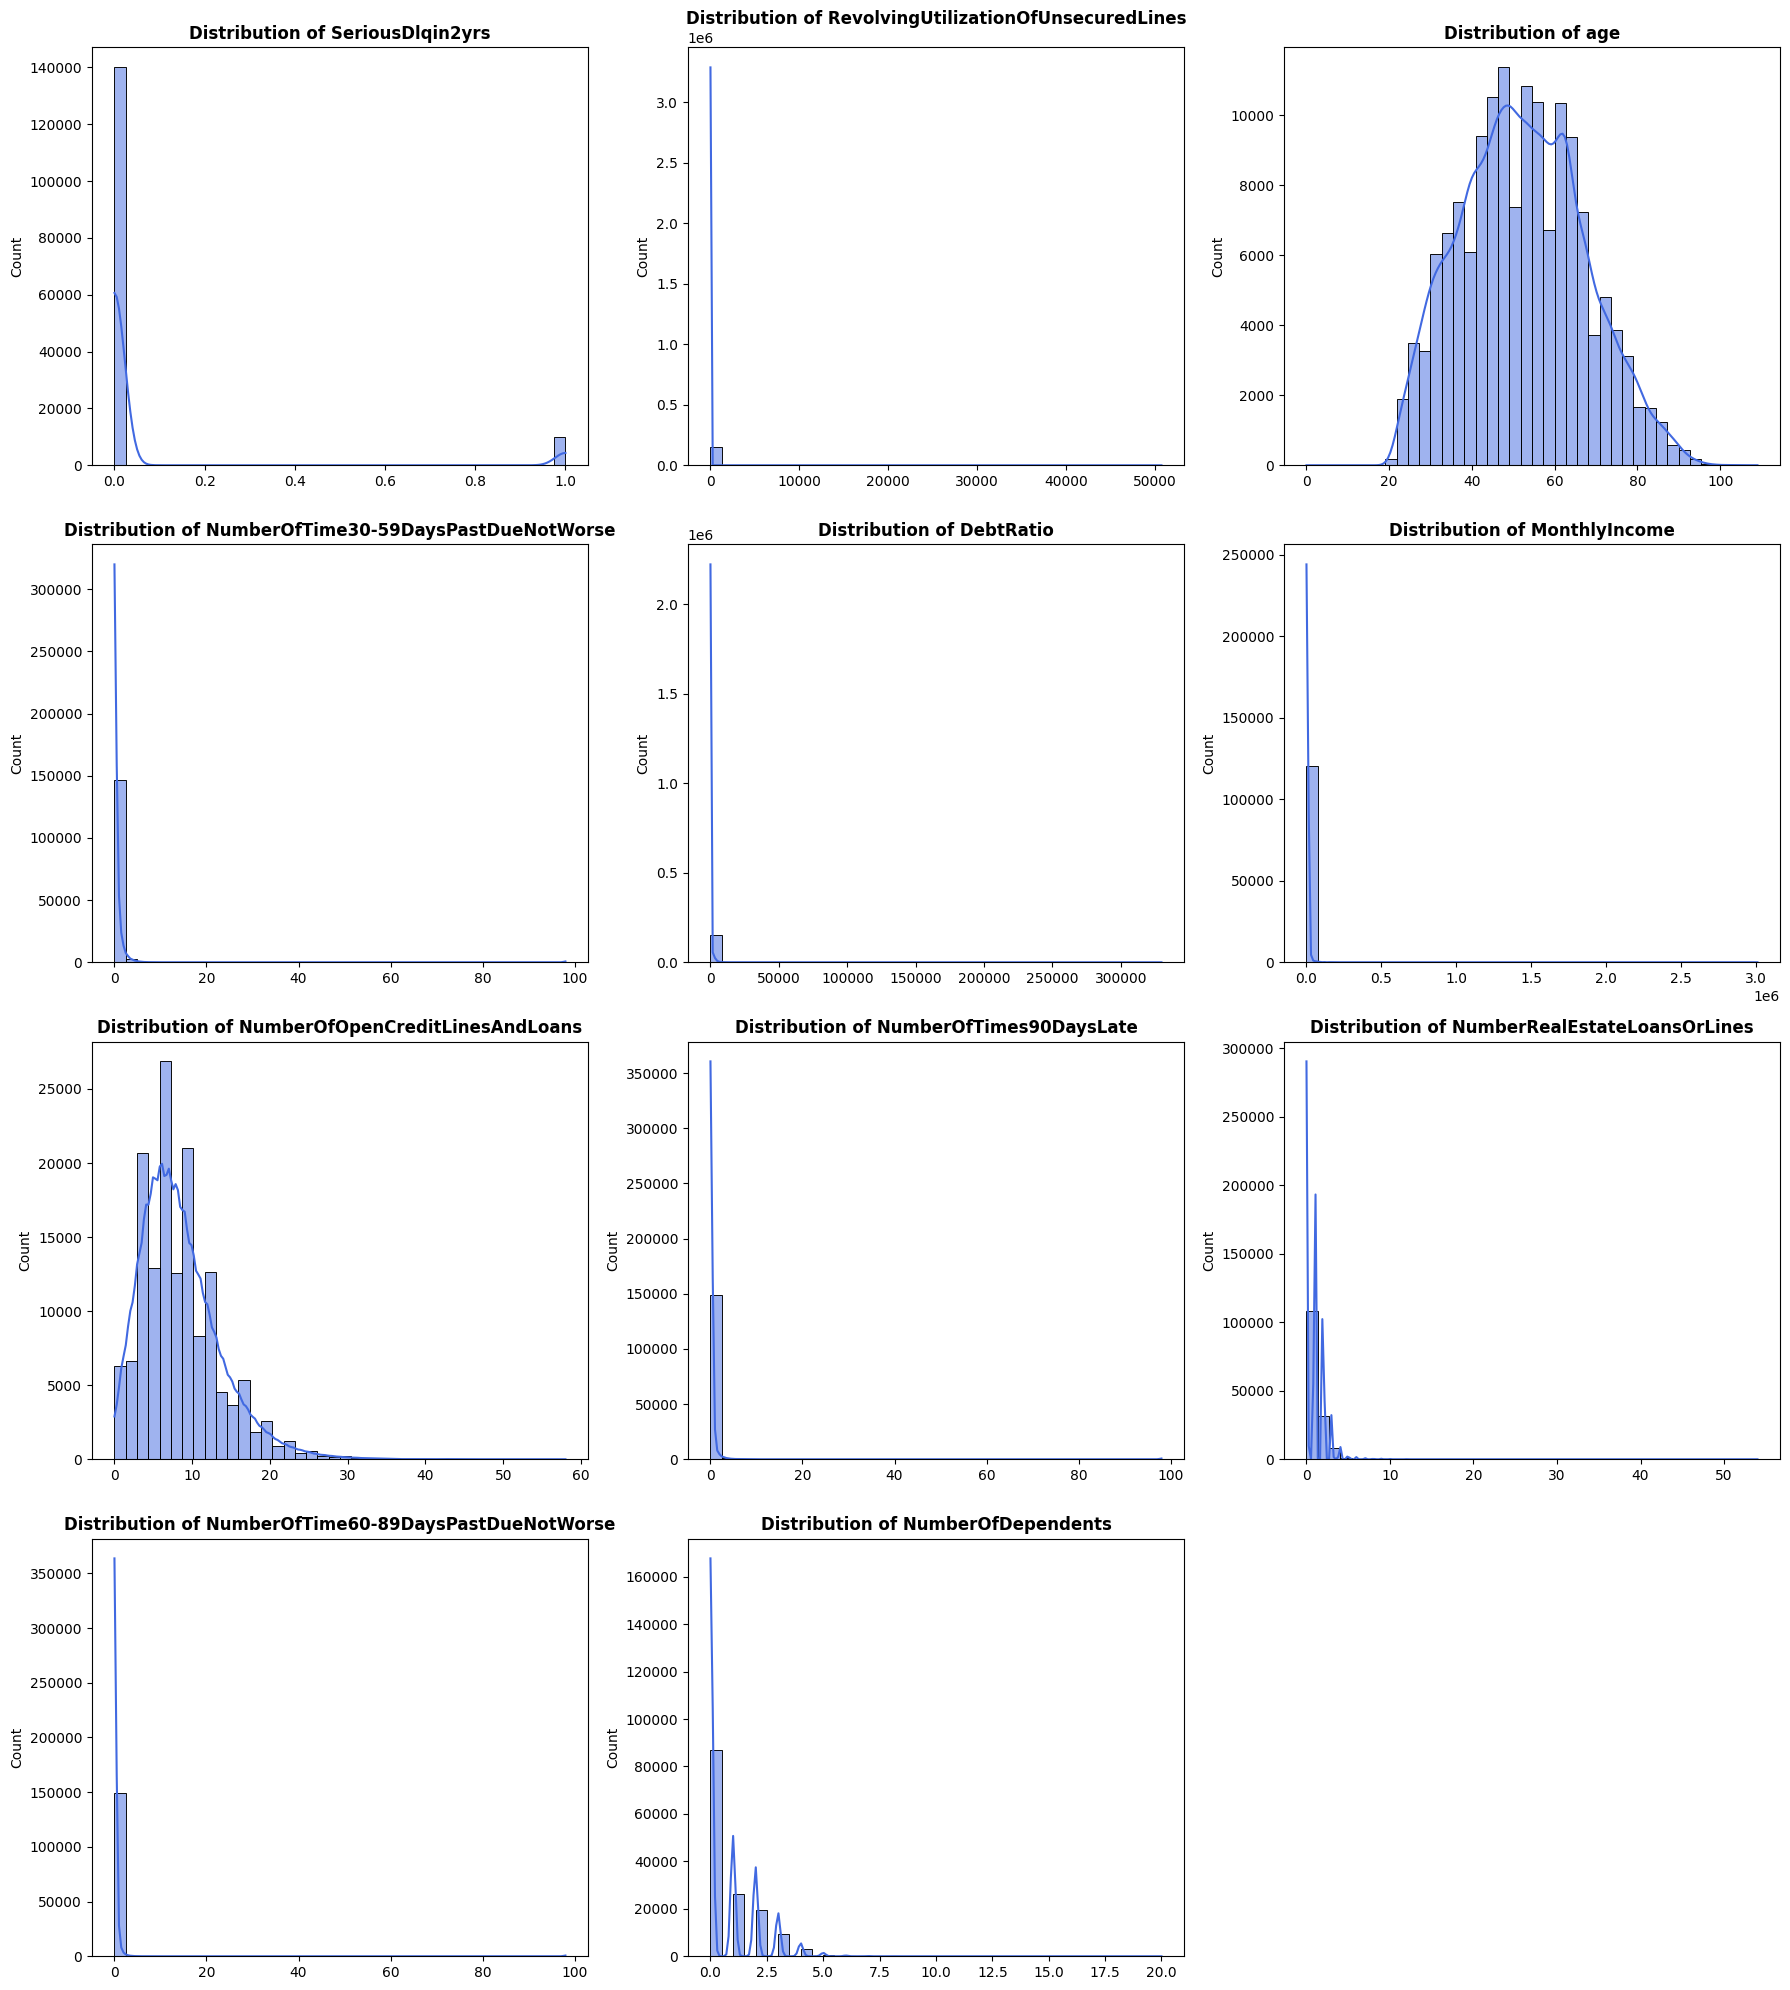

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Plotting Distributions for All Features ---")

# 1. Select numerical columns (excluding 'Id' since it's just a sequence)
cols_to_plot = [col for col in train_data.columns if col.lower() != 'id']

# 2. Set up the matplotlib figure (Grid of 4 rows and 3 columns)
# Adjust figsize if you need the charts to be larger or smaller
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten() # Flatten to loop through easily

# 3. Loop through columns and plot a Histogram with KDE
for i, col in enumerate(cols_to_plot):
    # We use a small number of bins for speed, and KDE to see the shape
    sns.histplot(train_data[col], bins=40, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# 4. Remove any empty subplots (if we have less than 12 columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Display the plots neatly
plt.tight_layout()
plt.show()

--- Plotting Distributions for All Features ---


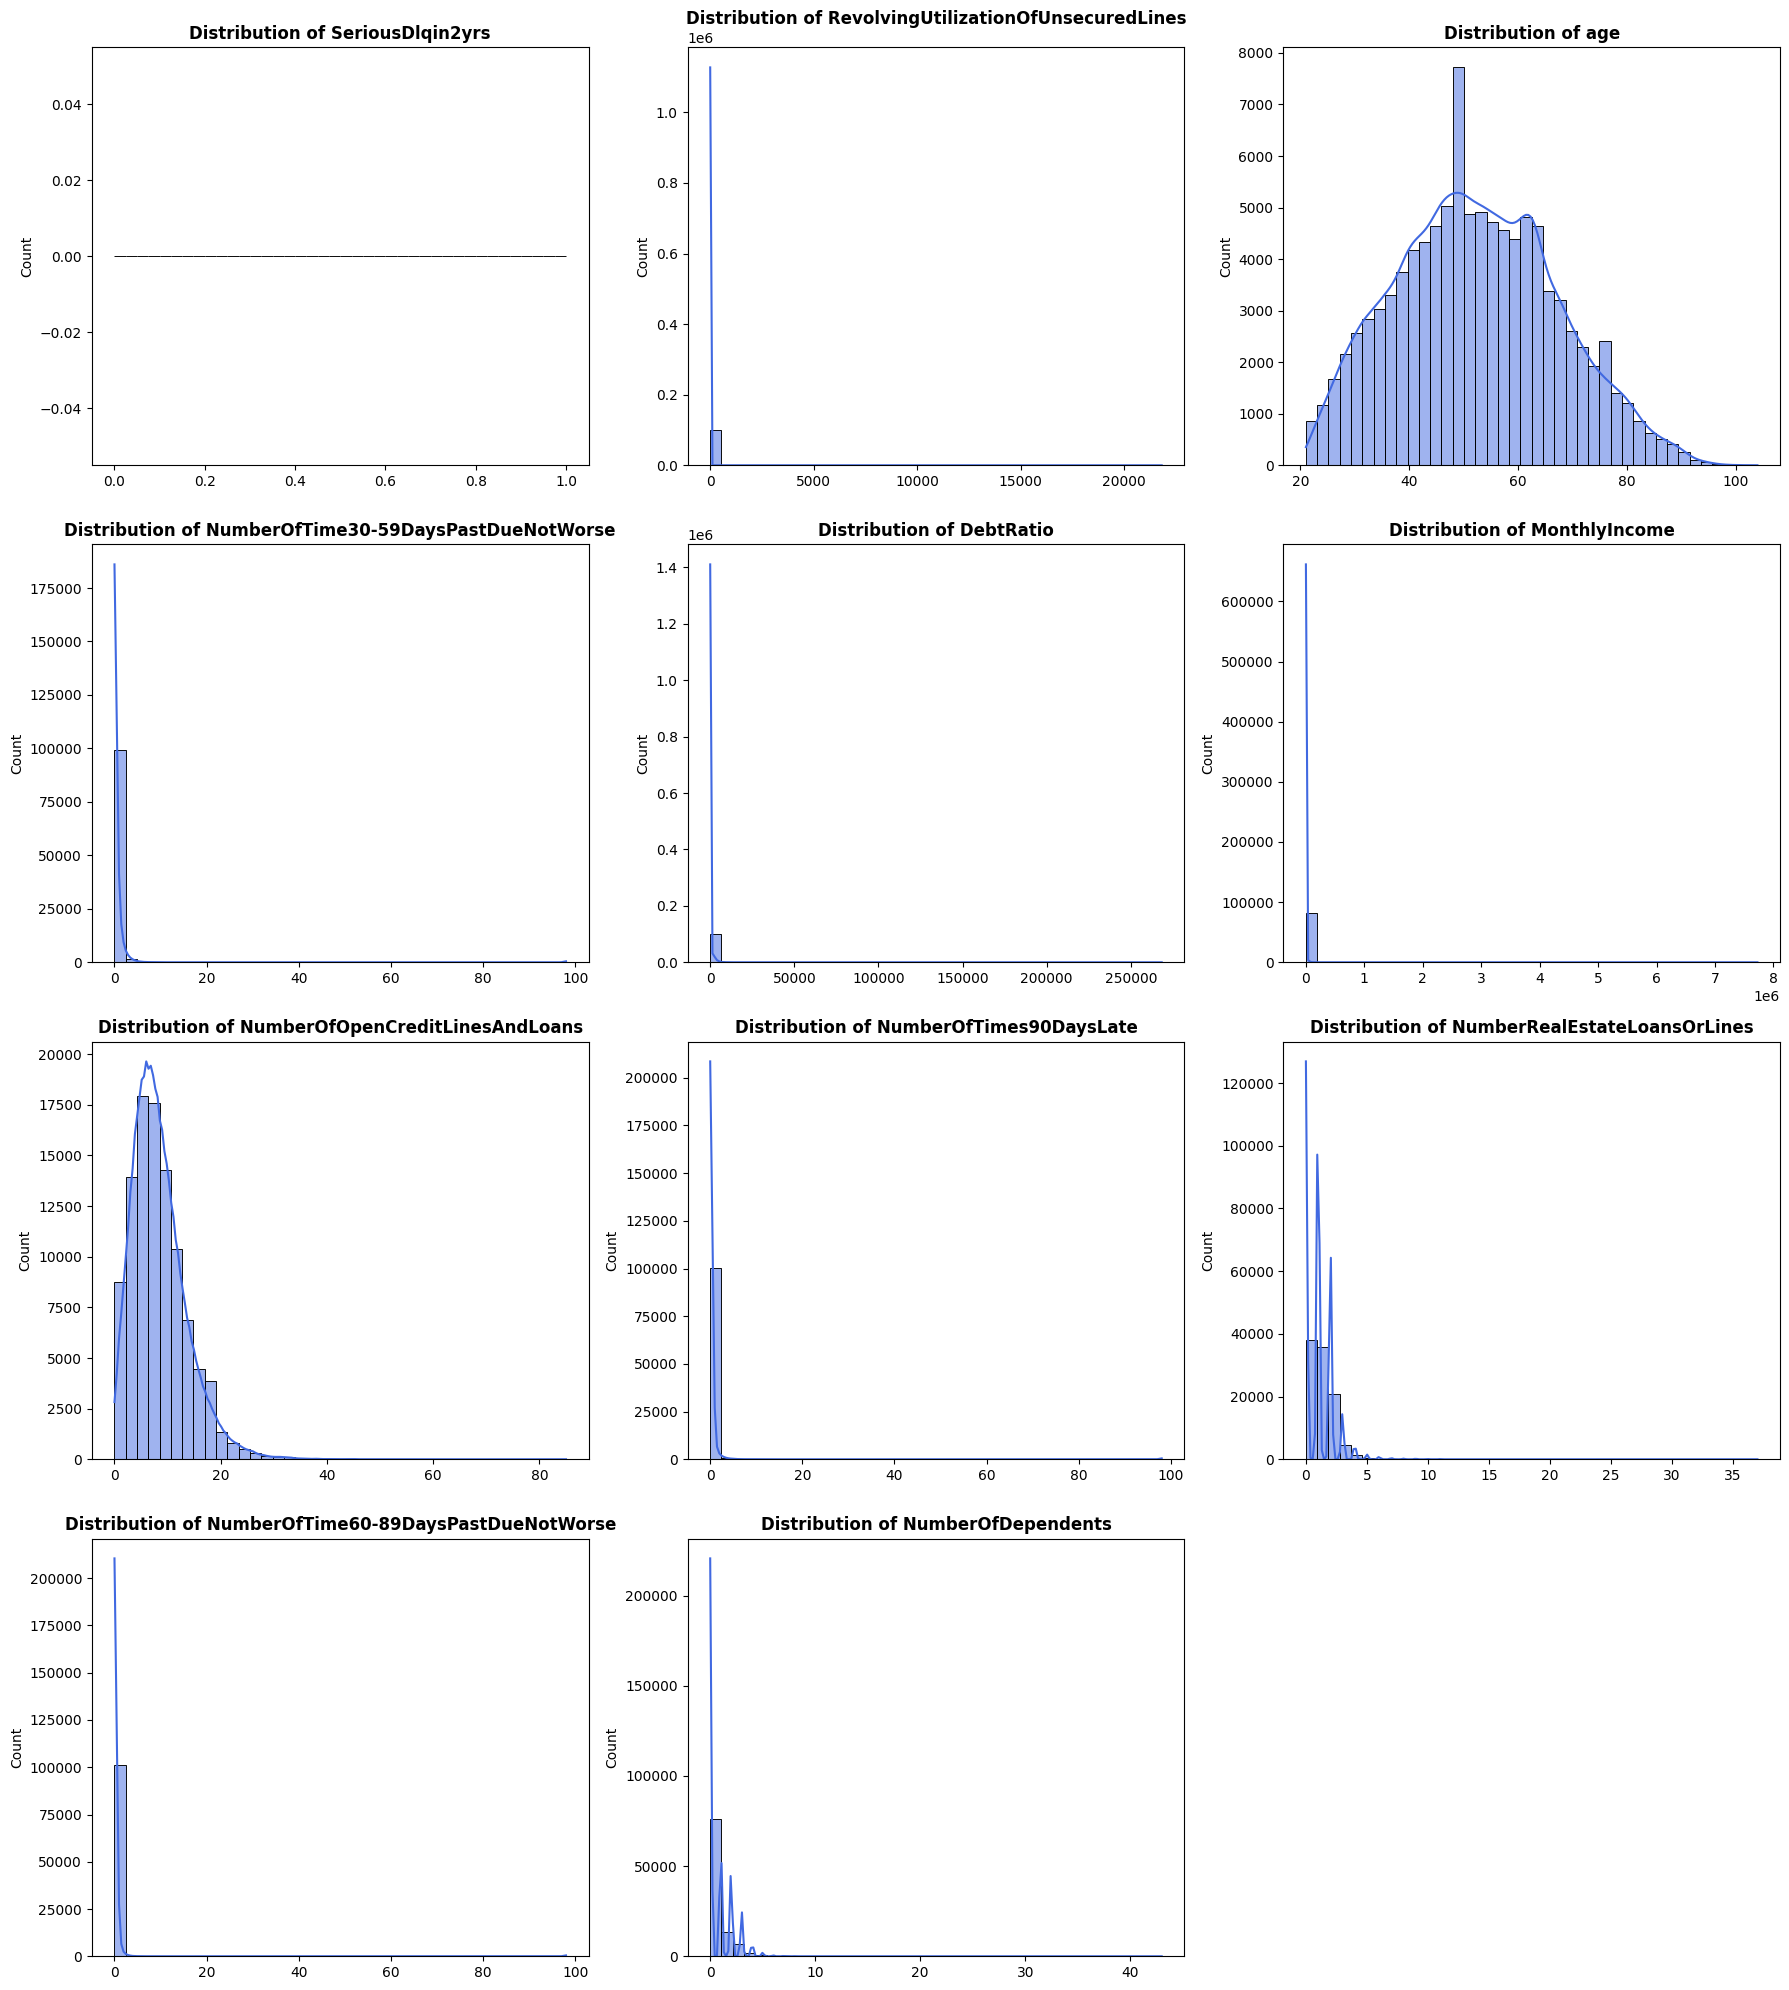

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Plotting Distributions for All Features ---")

# 1. Select numerical columns (excluding 'Id' since it's just a sequence)
cols_to_plot = [col for col in test_data.columns if col.lower() != 'id']

# 2. Set up the matplotlib figure (Grid of 4 rows and 3 columns)
# Adjust figsize if you need the charts to be larger or smaller
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten() # Flatten to loop through easily

# 3. Loop through columns and plot a Histogram with KDE
for i, col in enumerate(cols_to_plot):
    # We use a small number of bins for speed, and KDE to see the shape
    sns.histplot(test_data[col], bins=40, kde=True, ax=axes[i], color='royalblue')
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# 4. Remove any empty subplots (if we have less than 12 columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Display the plots neatly
plt.tight_layout()
plt.show()

## Outliers

--- Plotting Box Plots to Detect Outliers ---


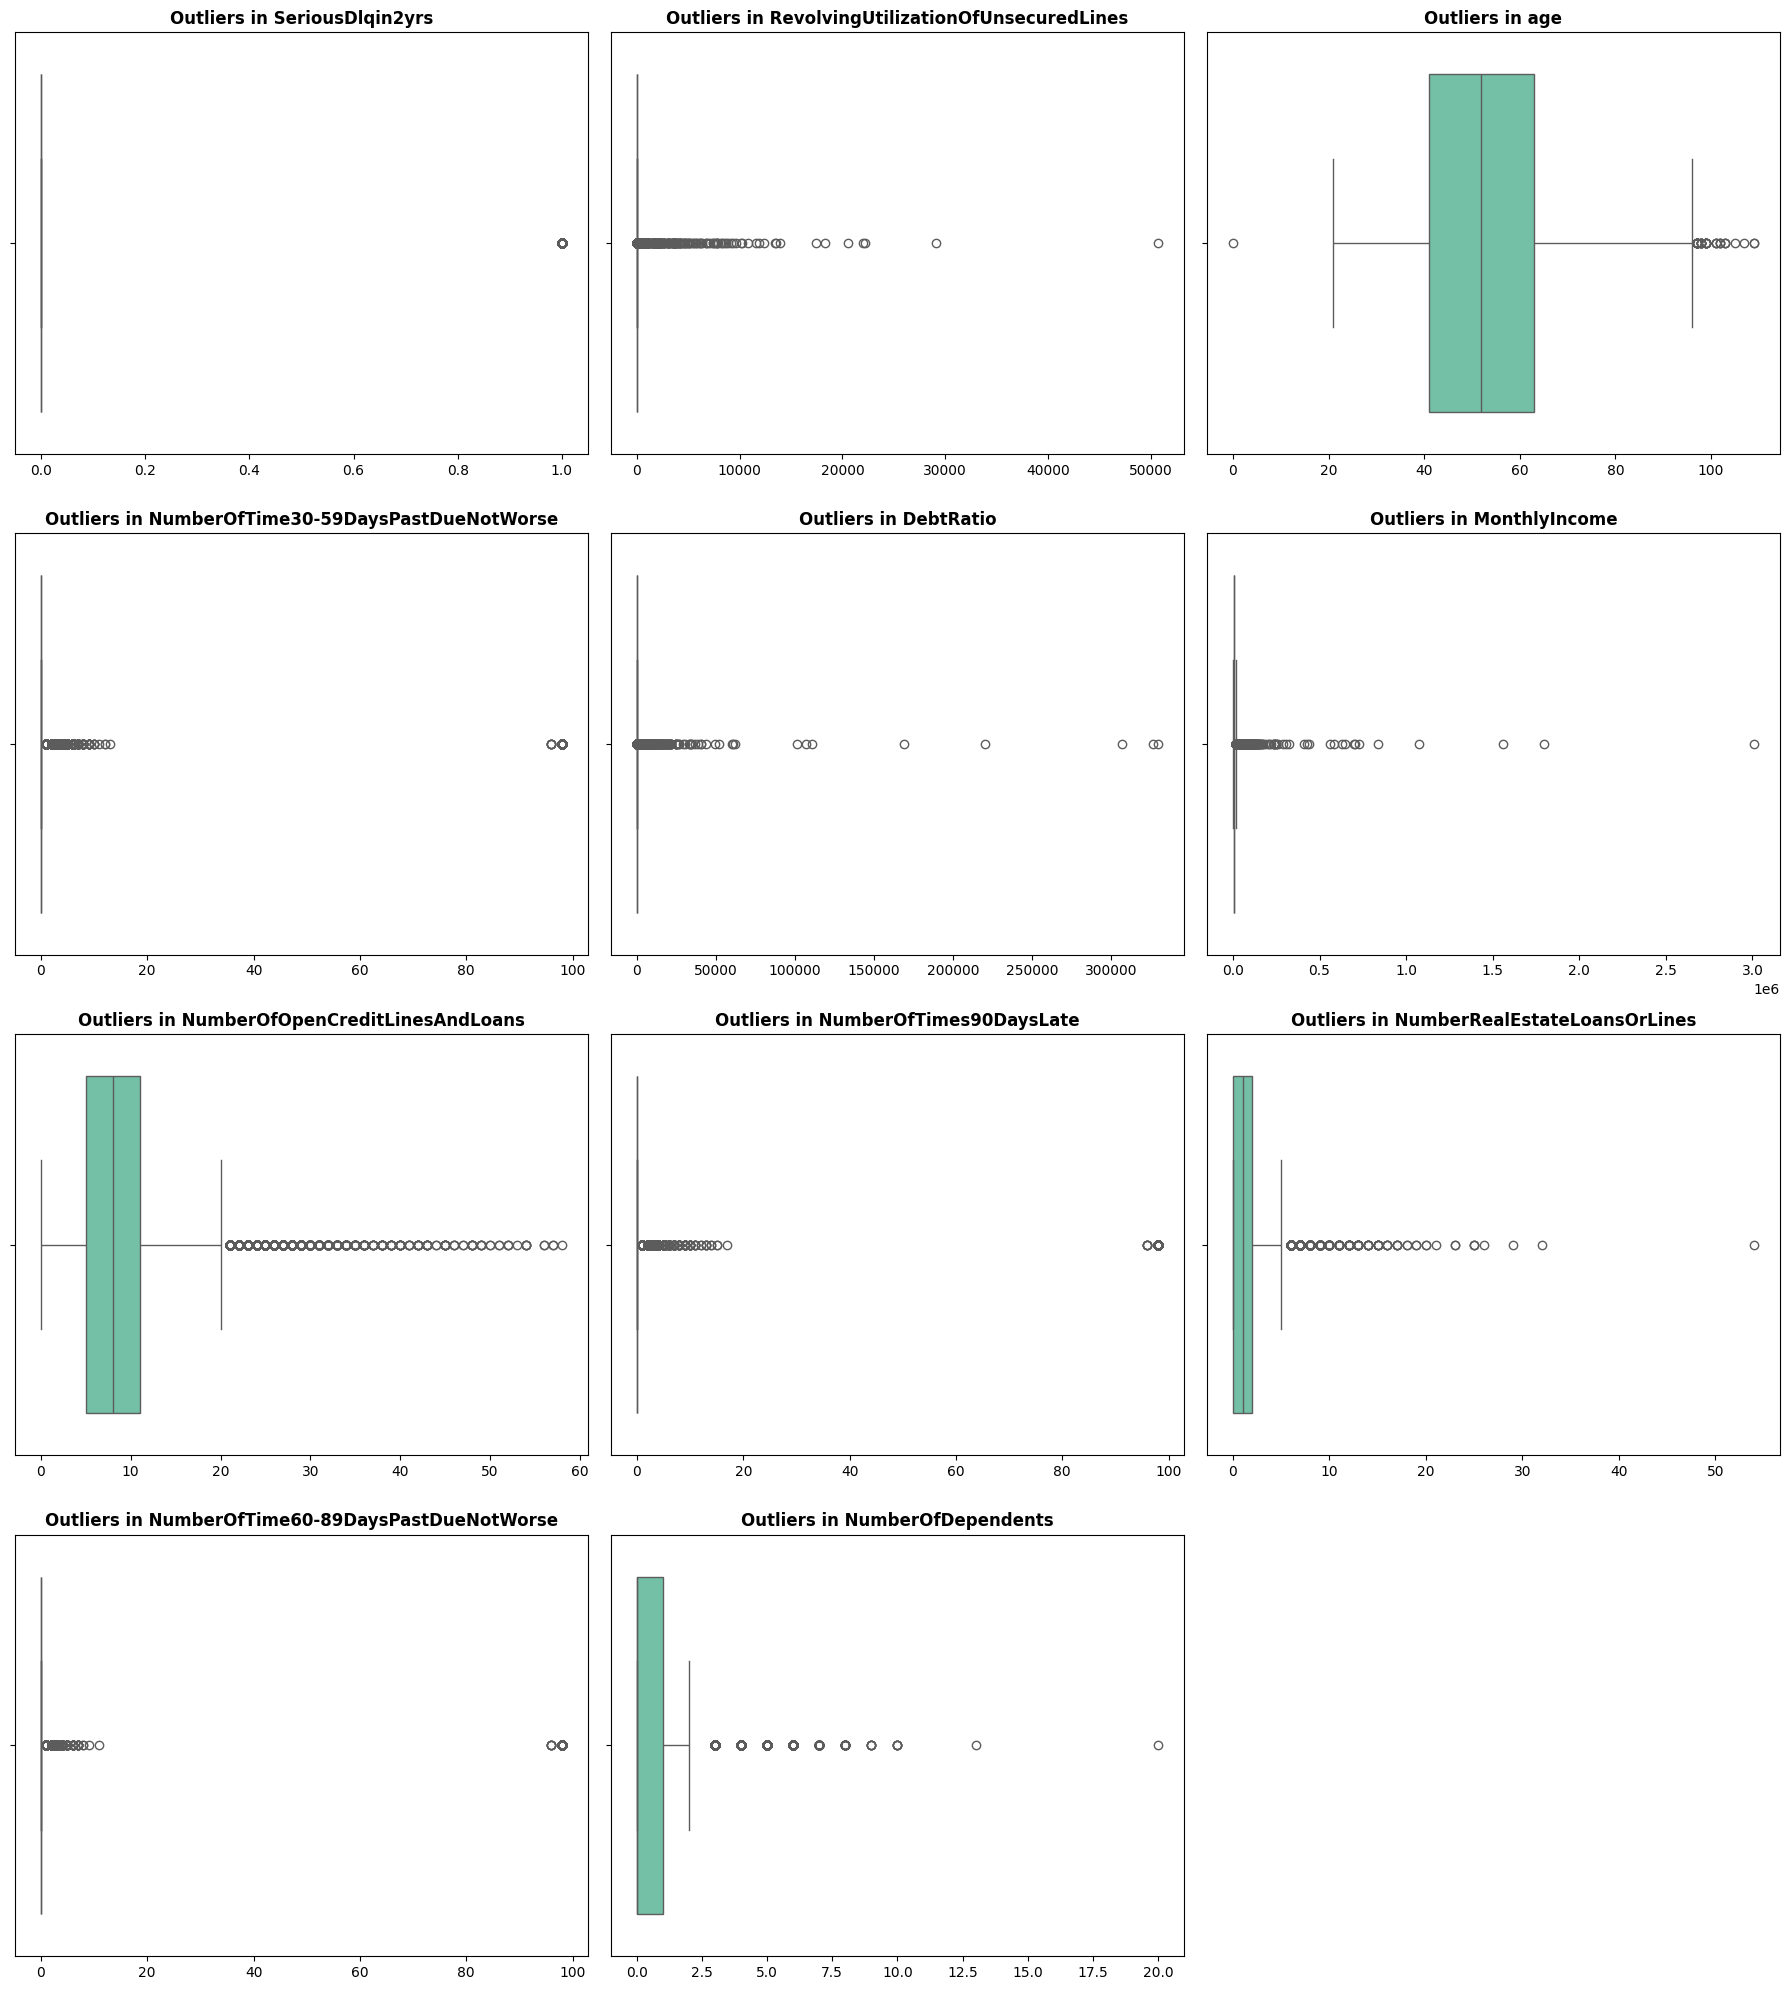

In [105]:
print("--- Plotting Box Plots to Detect Outliers ---")

# 1. Select numerical columns (excluding 'Id')
cols_to_plot = [col for col in train_data.columns if col.lower() != 'id']

# 2. Set up the figure (Grid of 4 rows and 3 columns)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten() # Flatten to loop easily

# 3. Loop through columns and plot a Box Plot
for i, col in enumerate(cols_to_plot):
    # 'orient=h' makes it horizontal which is often easier to read for outliers
    sns.boxplot(x=train_data[col], ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
# 4. Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Display the plots neatly
plt.tight_layout()
plt.show()

--- Plotting Box Plots to Detect Outliers ---


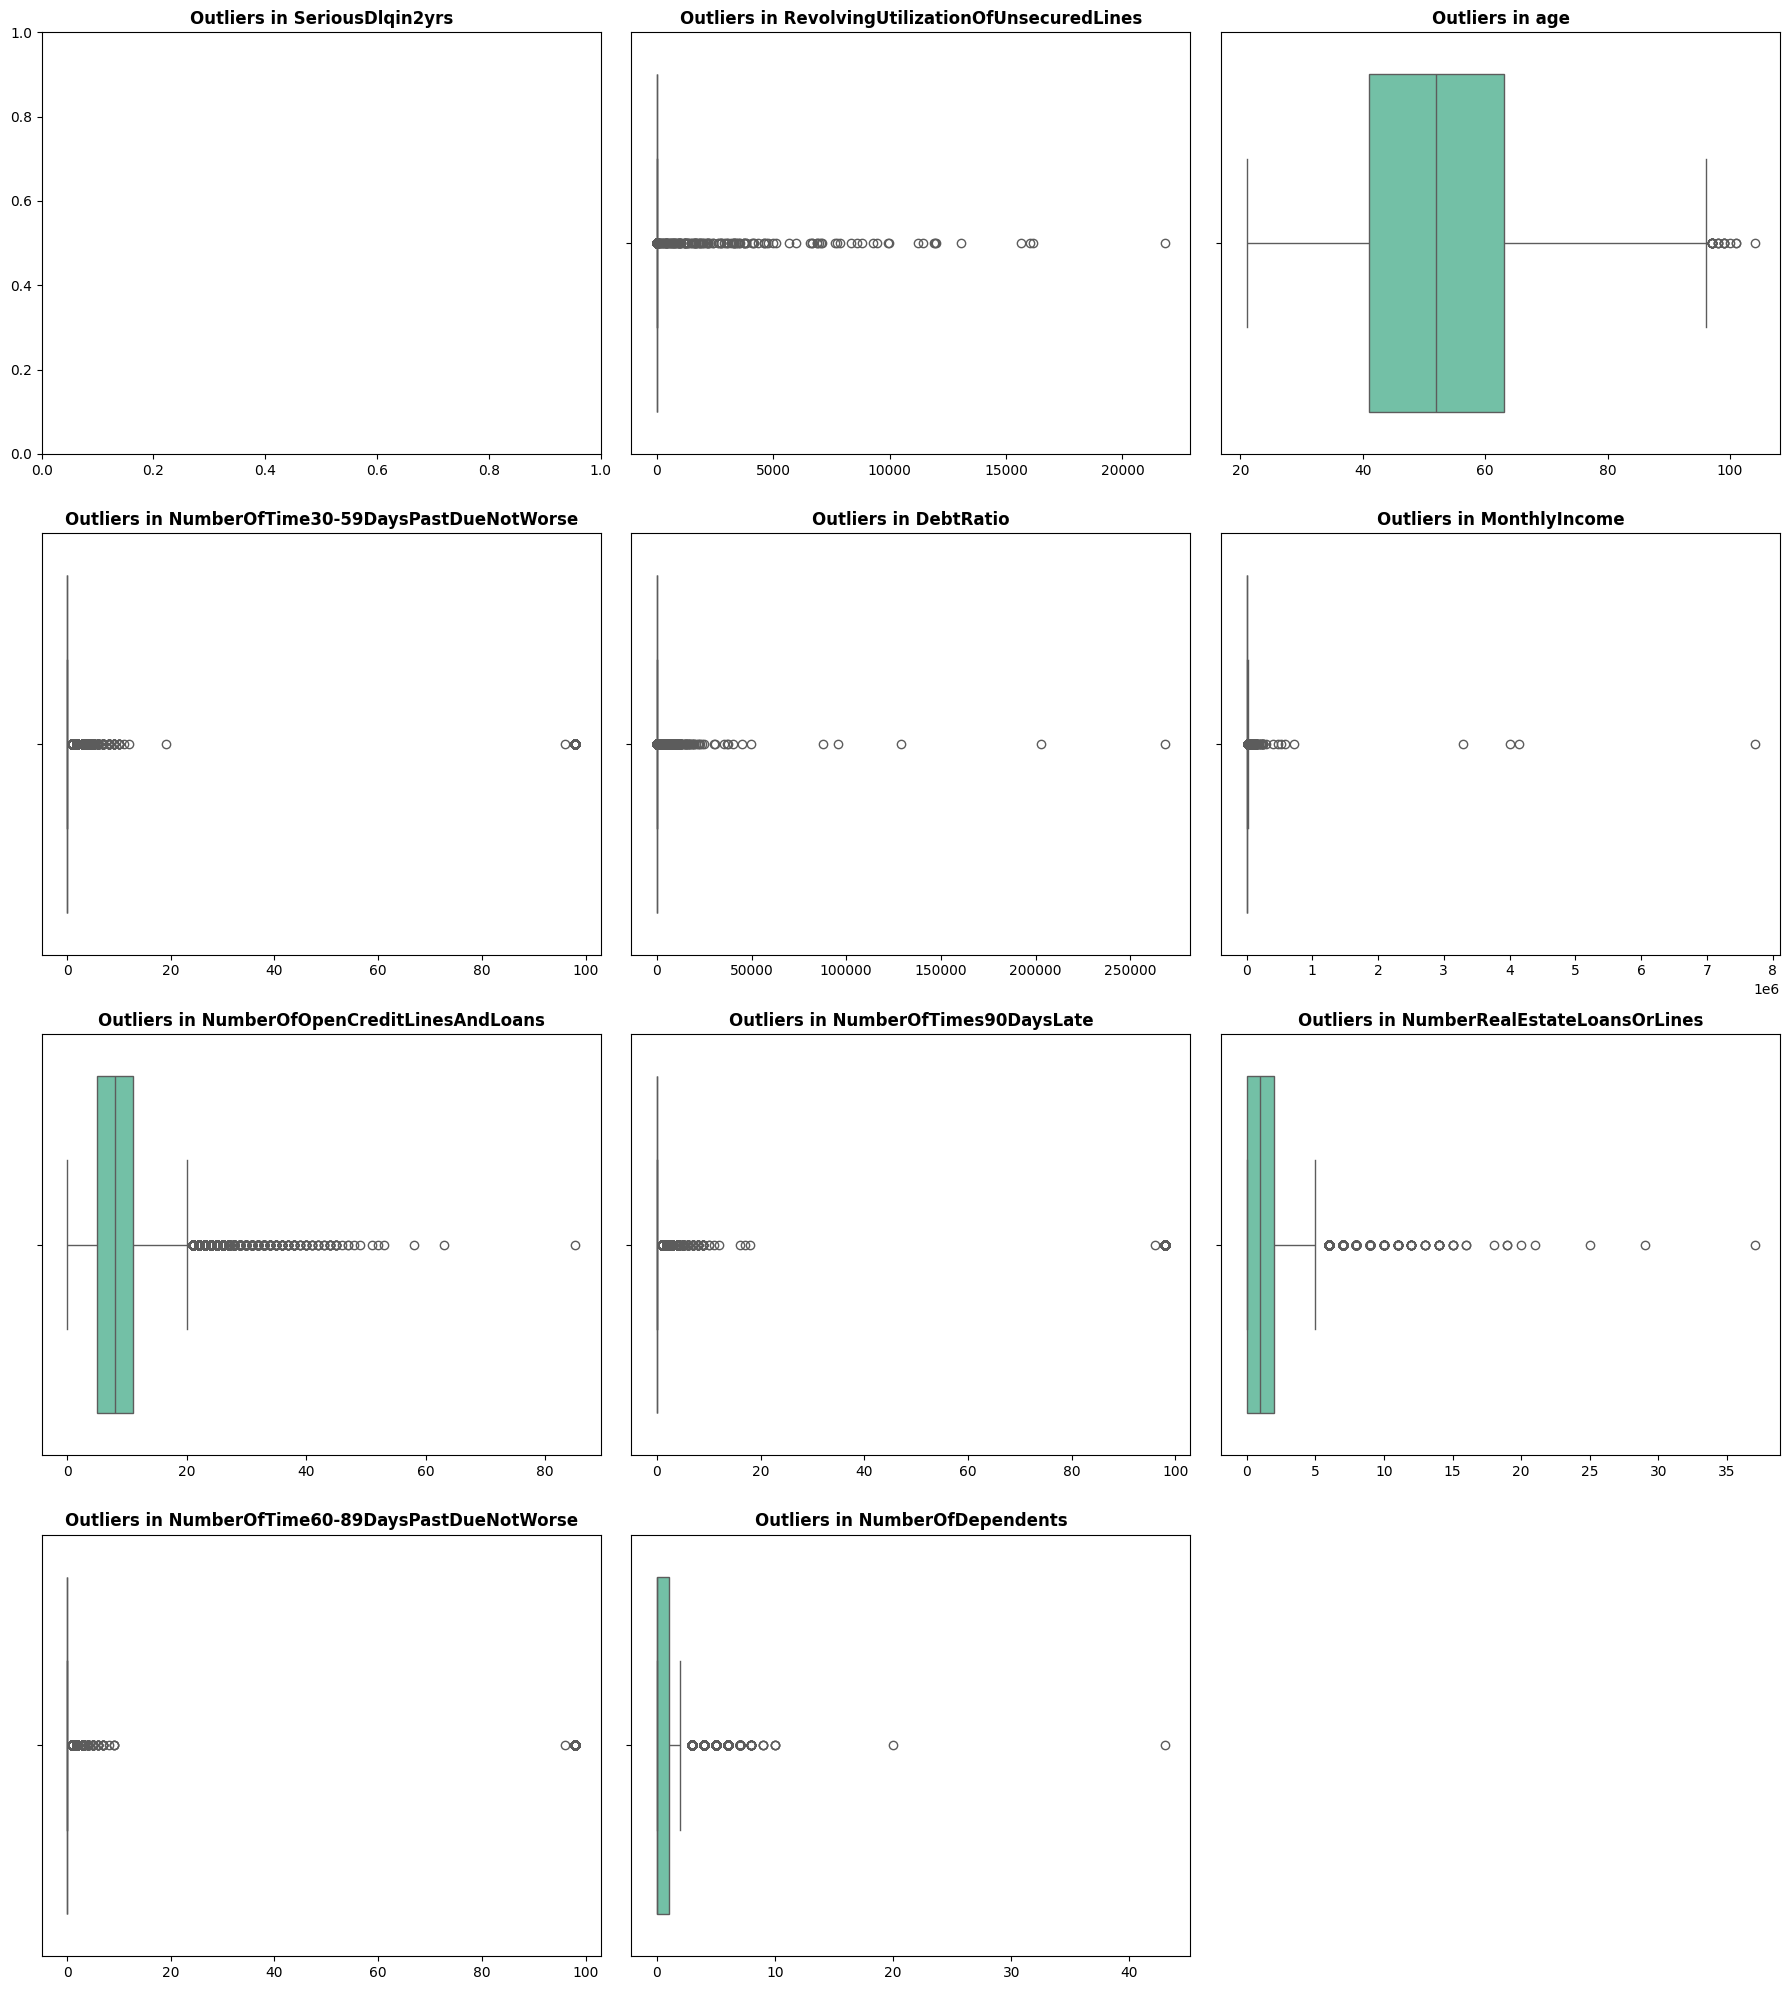

In [107]:
print("--- Plotting Box Plots to Detect Outliers ---")

# 1. Select numerical columns (excluding 'Id')
cols_to_plot = [col for col in test_data.columns if col.lower() != 'id']

# 2. Set up the figure (Grid of 4 rows and 3 columns)
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 20))
axes = axes.flatten() # Flatten to loop easily

# 3. Loop through columns and plot a Box Plot
for i, col in enumerate(cols_to_plot):
    # 'orient=h' makes it horizontal which is often easier to read for outliers
    sns.boxplot(x=test_data[col].dropna(), ax=axes[i], color='mediumaquamarine')
    axes[i].set_title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
# 4. Remove any extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Display the plots neatly
plt.tight_layout()
plt.show()